In [6]:
import numpy as np
import pandas as pd
import random
from matplotlib import pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [7]:
# activation func
f = lambda x: x > 0


def neuron(X):
    X = np.array([X[0], X[1], 1])
    w1 = [1, -1, 0.5]
    w2 = [1, -1, -0.5]
    w3 = [1, 1, -0.5]
    w4 = [1, 1, -1.5]
    w_hidden = np.array([w1, w2, w3, w4])
    w_out = np.array([1, -1, 1, -1, -1])

    z = w_hidden @ X
    out = np.array([f(x) for x in z] + [1])
    pred = w_out @ out
    y = f(pred)
    return y


def make_dataset():
    data = []
    for _ in range(100):
        x1 = random.uniform(0, 1)
        x2 = random.uniform(0, 1)
        X = [x1, x2]
        result = int(neuron(X))

        data.append([x1, x2, result])

    return pd.DataFrame(data=data, columns=["x1", "x2", "y"])


In [8]:
data = make_dataset()

In [9]:
def plot_zoo(data: pd.DataFrame, cat_img_path: str, dog_img_path: str):
    fig, ax = plt.subplots()

    ax.plot([0, 0.5], [0.5, 1], color='red')
    ax.plot([0.5, 1], [0, 0.5], color='red')
    ax.plot([0, 0.5], [0.5, 0], color='red')
    ax.plot([1, 0.5], [0.5, 1], color='red')

    cat_img = plt.imread(cat_img_path)
    dog_img = plt.imread(dog_img_path)

    for _, row in data.iterrows():
        img = cat_img if row['y'] == 0 else dog_img
        imagebox = OffsetImage(img, zoom=0.1)
        ab = AnnotationBbox(imagebox, (row['x1'], row['x2']), frameon=False)
        ax.add_artist(ab)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title("Котики vs Собачки")
    ax.grid(True)
    plt.show()

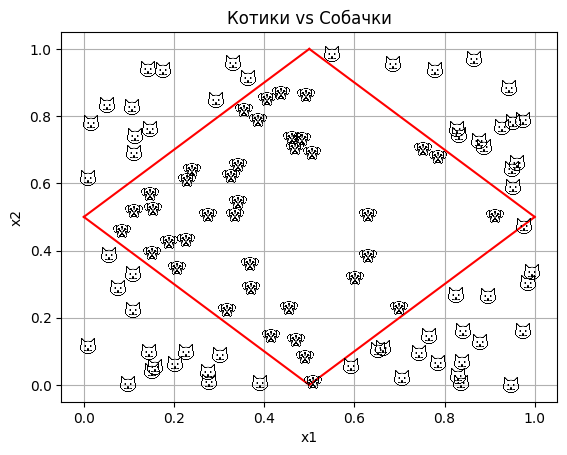

In [10]:
plot_zoo(data, "cat.png", "dog.png")